# Моделирование парадокса игрока

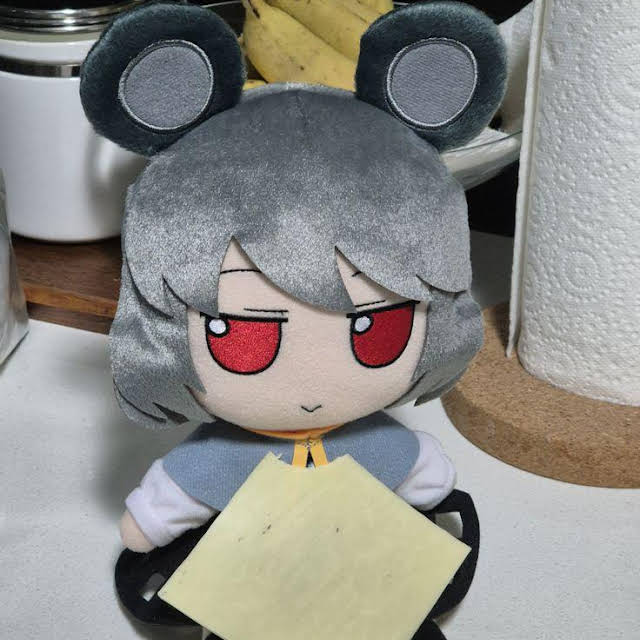

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objs as go

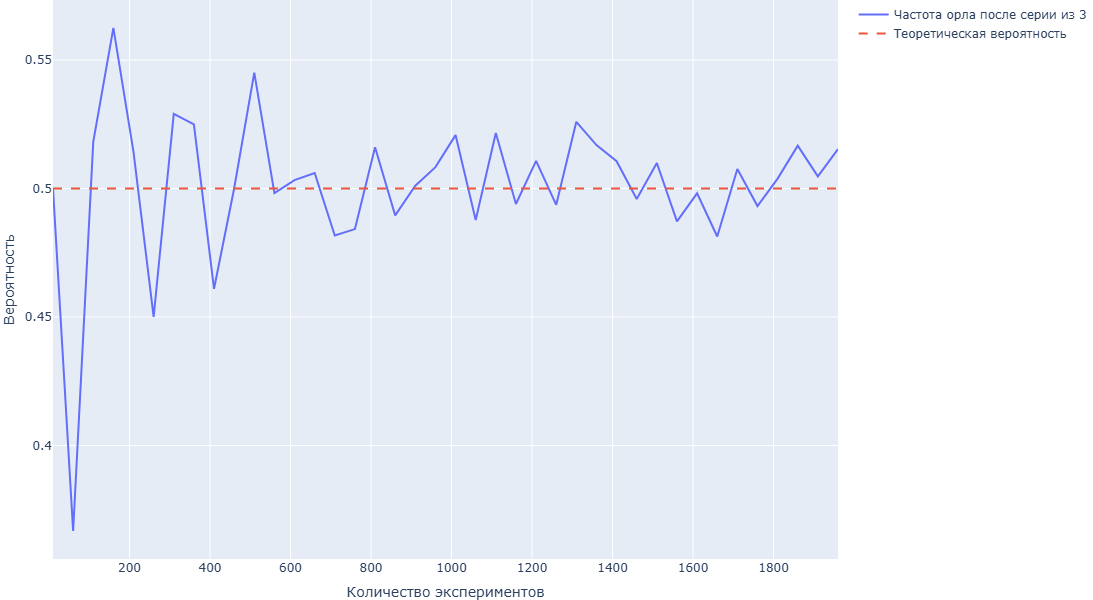

In [29]:
def gambler_fallacy(n, count, p):
    cnt = 0
    for _ in range(n):
        flips = np.random.choice([0, 1], size=1000, p=[1-p, p])
        flag = True
        while flag:
            for i in range(len(flips) - count):
                segment = flips[i:i+count]
                if np.all(segment == False):
                    if i + count < len(flips):
                        if flips[i+count] == True:
                            cnt += 1
                    flag = False
                    break 
    return cnt


count = 3
p = 1/2

n_values = np.array(range(10, 2000, 50))
p_values = []
for n in n_values:
    p_values.append(gambler_fallacy(n, count, p) / n)

p = [p] * len(p_values)

fig = go.Figure(layout=dict(width=800, height=600))
fig.update_layout(margin=dict(l=0, t=0, b=0))
fig.add_trace(go.Scatter(x=n_values, y=p_values, name=f'Частота орла после серии из {count}'))
fig.add_trace(go.Scatter(x=n_values, y=p, name='Теоретическая вероятность', line_dash='dash'))
fig.update_xaxes(title_text='Количество экспериментов')
fig.update_yaxes(title_text='Вероятность')
fig.show();

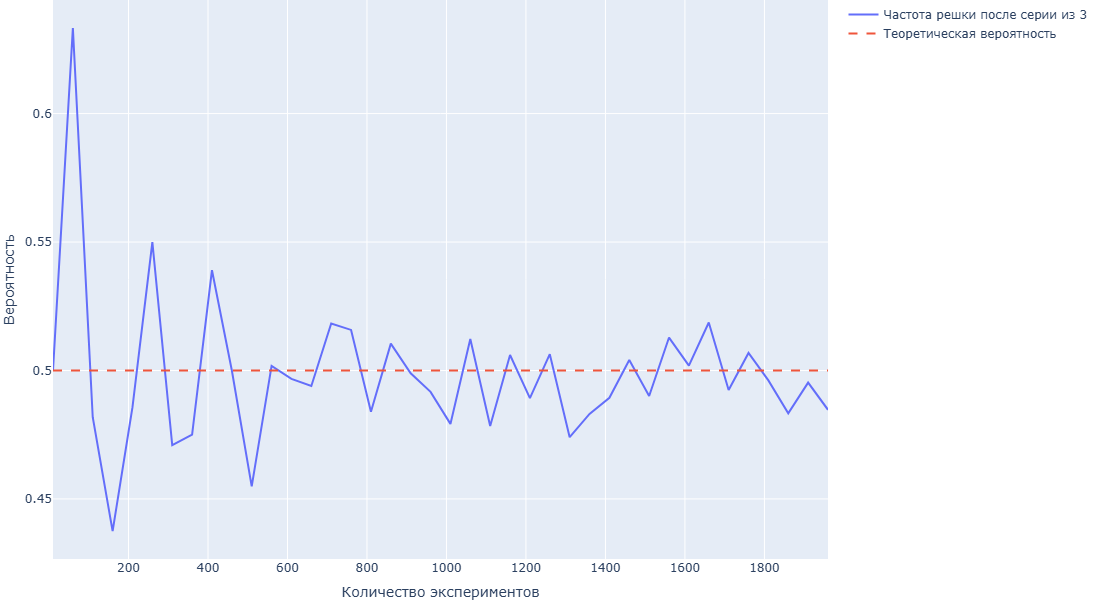

In [30]:
p_values = [abs(1 - p) for p in p_values]

fig = go.Figure(layout=dict(width=800, height=600))
fig.update_layout(margin=dict(l=0, t=0, b=0))
fig.add_trace(go.Scatter(x=n_values, y=p_values, name=f'Частота решки после серии из {count}'))
fig.add_trace(go.Scatter(x=n_values, y=p, name='Теоретическая вероятность', line_dash='dash'))
fig.update_xaxes(title_text='Количество экспериментов')
fig.update_yaxes(title_text='Вероятность')
fig.show();